# Daten einlesen und erster Überblick

In [1]:
import pandas as pd
import xarray as xr

from myproj.io.import_data import load_raw_data

import myproj
print(myproj.__file__)

/Users/yanisweber/Library/Mobile Documents/com~apple~CloudDocs/Module/Module_4/daw/DAW_FS26/.venv/lib/python3.14/site-packages/myproj/__init__.py


## Daten einlesen (raw)

In [2]:
emdat = load_raw_data("public_emdat_1991_2024.xlsx")
climate = load_raw_data("omi_climate_sl_medsea_area_averaged_anomalies_19990220_P20250729.nc")

## EDA für EM-DAT

In [3]:
print("EM-DAT shape:", emdat.shape)
display(emdat.head())

EM-DAT shape: (20657, 47)


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2018-0040-BRA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),DFO:4576,NaN,BRA,...,NaN,NaN,NaN,10000.0,12492.0,80.049596,"[{""adm2_code"":9961,""adm2_name"":""Rio De Janeiro""}]","[{""gid_2"":""BRA.19.68_2"",""migration_date"":""2025...",2018-02-20,2025-12-20
1,2002-0351-USA,No,nat-cli-wil-for,Natural,Climatological,Wildfire,Forest fire,NaN,NaN,USA,...,NaN,NaN,NaN,20000.0,34879.0,57.341840,"[{""adm1_code"":3219,""adm1_name"":""Colorado""}]","[{""gid_1"":""USA.6_1"",""migration_date"":""2025-12-...",2003-07-01,2025-12-20
2,1990-9604-BWA,Yes,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,BWA,...,NaN,NaN,NaN,NaN,NaN,44.731153,NaN,NaN,2006-02-13,2025-03-14
3,1990-9604-LSO,Yes,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,LSO,...,NaN,NaN,NaN,NaN,NaN,44.731153,NaN,NaN,2006-02-13,2025-03-14
4,1990-9604-MOZ,Yes,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,MOZ,...,NaN,NaN,NaN,50000.0,115164.0,43.416157,NaN,NaN,2007-05-05,2025-03-14


In [4]:
emdat.info()

<class 'pandas.DataFrame'>
RangeIndex: 20657 entries, 0 to 20656
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     20657 non-null  str    
 1   Historic                                   20657 non-null  str    
 2   Classification Key                         20657 non-null  str    
 3   Disaster Group                             20657 non-null  str    
 4   Disaster Subgroup                          20657 non-null  str    
 5   Disaster Type                              20657 non-null  str    
 6   Disaster Subtype                           20657 non-null  str    
 7   External IDs                               4376 non-null   str    
 8   Event Name                                 6697 non-null   str    
 9   ISO                                        20657 non-null  str    
 10  Country                          

In [5]:
emdat.columns.tolist()

['DisNo.',
 'Historic',
 'Classification Key',
 'Disaster Group',
 'Disaster Subgroup',
 'Disaster Type',
 'Disaster Subtype',
 'External IDs',
 'Event Name',
 'ISO',
 'Country',
 'Subregion',
 'Region',
 'Location',
 'Origin',
 'Associated Types',
 'OFDA/BHA Response',
 'Appeal',
 'Declaration',
 "AID Contribution ('000 US$)",
 'Magnitude',
 'Magnitude Scale',
 'Latitude',
 'Longitude',
 'River Basin',
 'Start Year',
 'Start Month',
 'Start Day',
 'End Year',
 'End Month',
 'End Day',
 'Total Deaths',
 'No. Injured',
 'No. Affected',
 'No. Homeless',
 'Total Affected',
 "Reconstruction Costs ('000 US$)",
 "Reconstruction Costs, Adjusted ('000 US$)",
 "Insured Damage ('000 US$)",
 "Insured Damage, Adjusted ('000 US$)",
 "Total Damage ('000 US$)",
 "Total Damage, Adjusted ('000 US$)",
 'CPI',
 'Admin Units',
 'GADM Admin Units',
 'Entry Date',
 'Last Update']

In [6]:
pd.DataFrame({
    "missing_count": emdat.isna().sum(),
    "missing_percent": (emdat.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False).head(20)

,missing_count,missing_percent
Reconstruction Costs ('000 US$),20615,99.80
"Reconstruction Costs, Adjusted ('000 US$)",20615,99.80
AID Contribution ('000 US$),19871,96.19
"Insured Damage, Adjusted ('000 US$)",19647,95.11
Insured Damage ('000 US$),19647,95.11
River Basin,19141,92.66
No. Homeless,18641,90.24
Longitude,18571,89.90
Latitude,18571,89.90
Associated Types,16872,81.68


In [7]:
emdat.describe(include="all")

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
count,20657,20657,20657,20657,20657,20657,20657,4376,6697,20657,...,4.200000e+01,1.010000e+03,1.010000e+03,4.344000e+03,4.344000e+03,20657.000000,8406,7765,20657,20657
unique,20657,2,65,2,9,31,65,3238,2822,226,...,NaN,NaN,NaN,NaN,NaN,NaN,6908,6379,2616,229
top,2018-0040-BRA,No,tec-tra-roa-roa,Natural,Hydrological,Flood,Road,GLIDE:HT-2022-000399,Cholera,CHN,...,NaN,NaN,NaN,NaN,NaN,NaN,"[{""adm1_code"":925,""adm1_name"":""Taiwan Sheng""}]","[{""gid_1"":""TWN.2_1"",""migration_date"":""2025-12-...",2003-07-01,2023-09-25
freq,1,16153,2677,12950,5545,4924,2677,33,432,1705,...,NaN,NaN,NaN,NaN,NaN,NaN,54,54,4497,10999
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.835296e+06,1.062495e+06,1.495715e+06,1.007389e+06,1.444073e+06,66.872831,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.749804e+07,3.987549e+06,5.392087e+06,5.678102e+06,8.207902e+06,14.540682,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.350000e+02,3.400000e+01,4.900000e+01,2.000000e+00,3.000000e+00,43.416157,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.006025e+05,6.000000e+04,1.000478e+05,1.224400e+04,2.051900e+04,54.895152,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.534020e+05,2.000000e+05,3.124455e+05,9.750000e+04,1.366240e+05,66.098103,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.552974e+06,6.775000e+05,1.002865e+06,4.635250e+05,6.746290e+05,75.557977,NaN,NaN,NaN,NaN


In [8]:
print("Anzahl Duplikate:", emdat.duplicated().sum())

Anzahl Duplikate: 0


In [ ]:
# Fehlende Werte pro Spalte
print("Anzahl Fehlender Werte:", emdat.isna().sum())

Anzahl Fehlender Werte: DisNo.                                           0
Historic                                         0
Classification Key                               0
Disaster Group                                   0
Disaster Subgroup                                0
Disaster Type                                    0
Disaster Subtype                                 0
External IDs                                 16281
Event Name                                   13960
ISO                                              0
Country                                          0
Subregion                                        0
Region                                           0
Location                                      1214
Origin                                       16087
Associated Types                             16872
OFDA/BHA Response                                0
Appeal                                           0
Declaration                                      0
AID Con

In [19]:
# Summe der fehlenden Werte
print("Gesamtanzahl Fehlender Werte:", emdat.isna().sum().sum())

Gesamtanzahl Fehlender Werte: 360835


In [16]:
# typen der Spalten
num_cols = emdat.select_dtypes(include="number").columns.tolist()
cat_cols = emdat.select_dtypes(include="object").columns.tolist()

print("Numerische Spalten:", num_cols)
print("Kategoriale Spalten:", cat_cols)

Numerische Spalten: ["AID Contribution ('000 US$)", 'Magnitude', 'Latitude', 'Longitude', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI']
Kategoriale Spalten: ['DisNo.', 'Historic', 'Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', 'Magnitude Scale', 'River Basin', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update']


/var/folders/81/rlsyxp115wn9ysg12rd_5vtw0000gn/T/ipykernel_61757/2450980827.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = emdat.select_dtypes(include="object").columns.tolist()


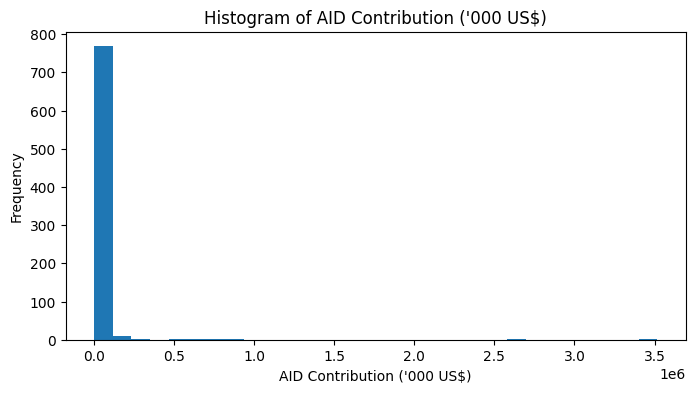

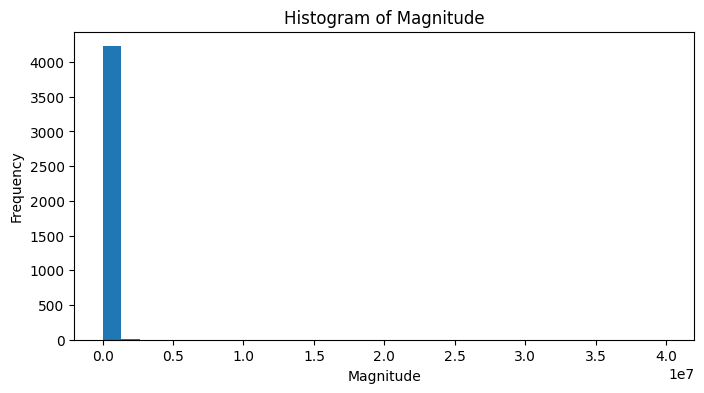

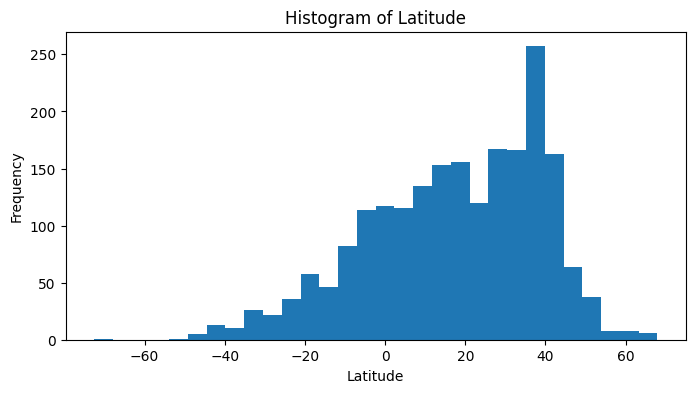

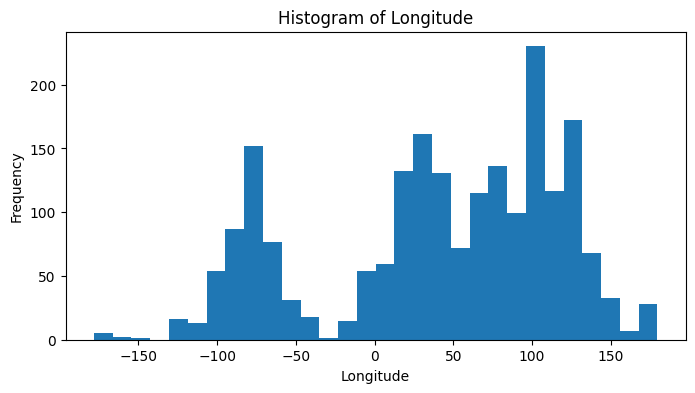

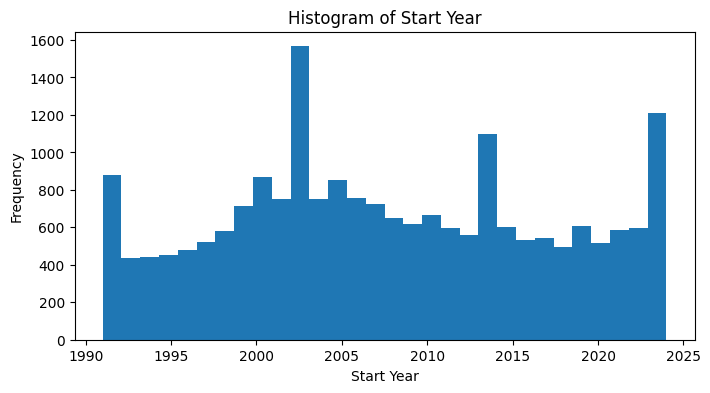

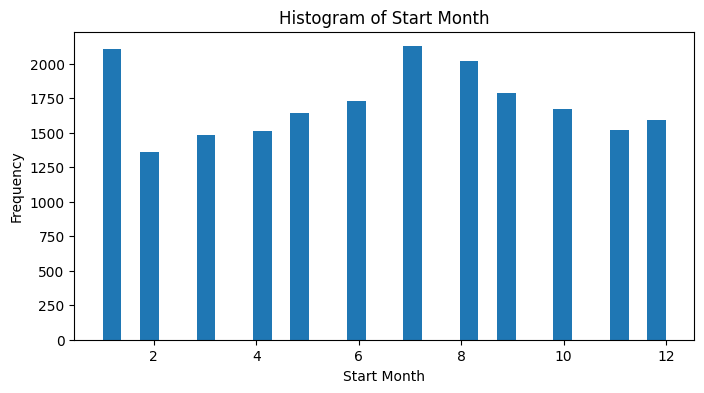

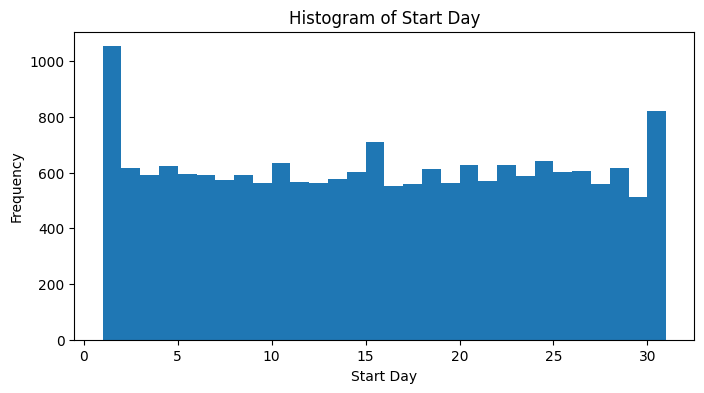

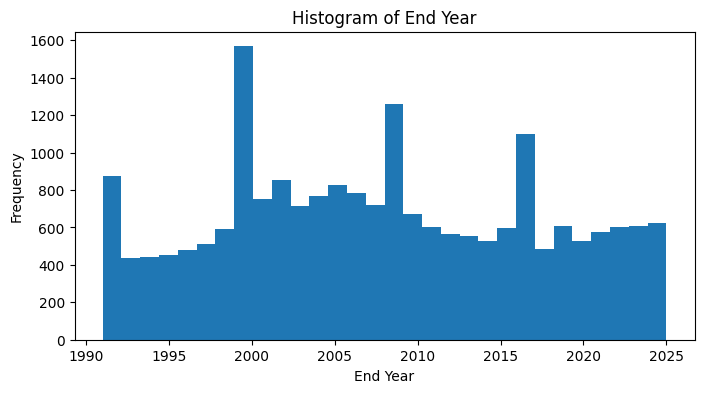

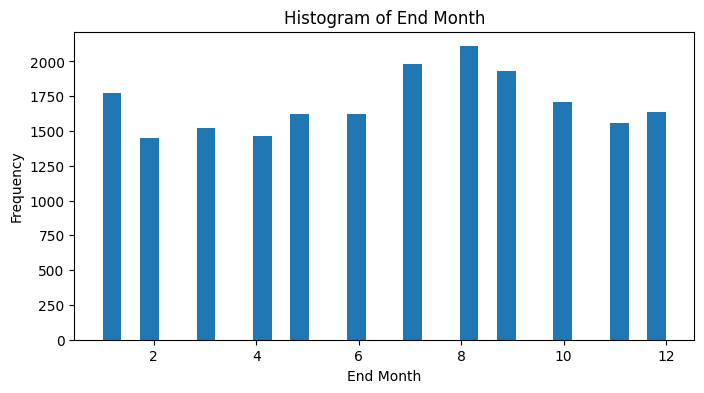

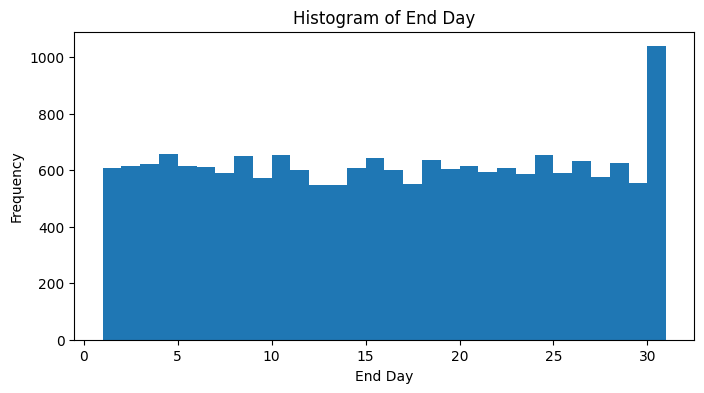

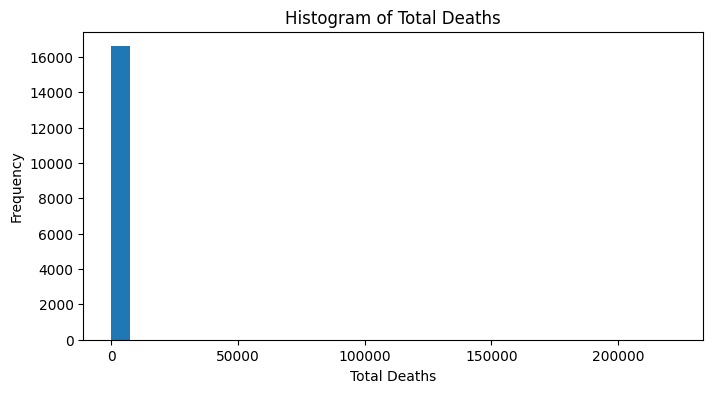

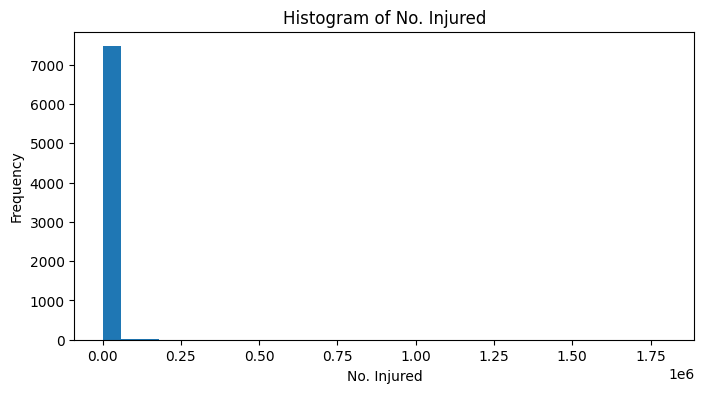

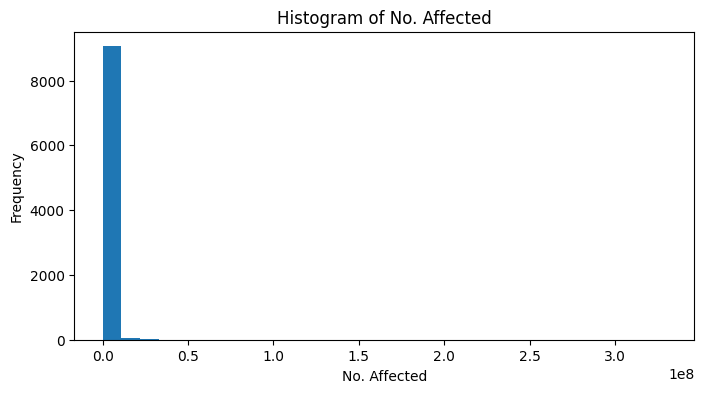

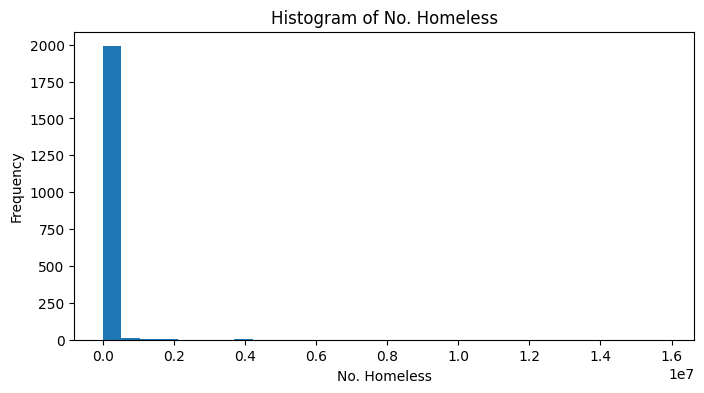

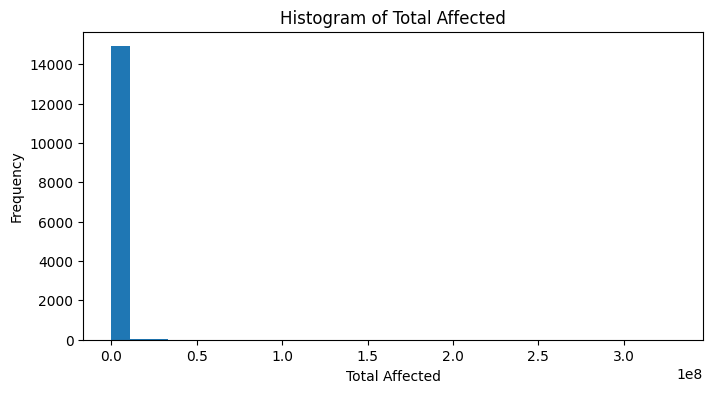

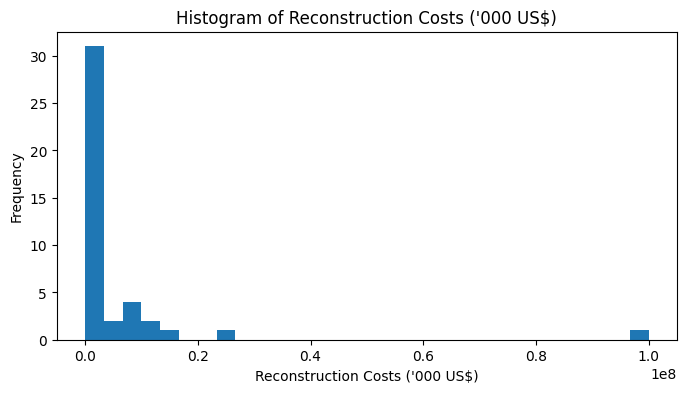

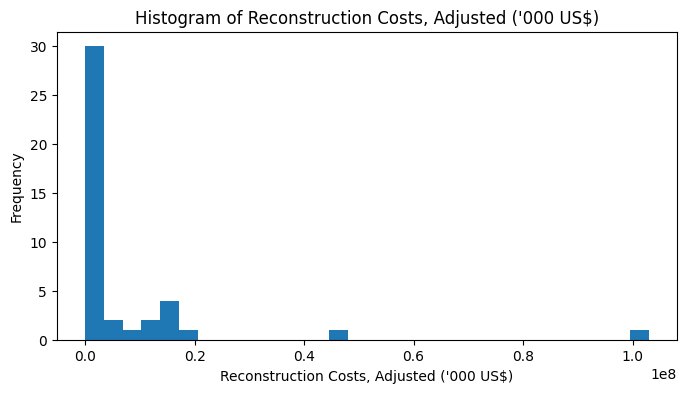

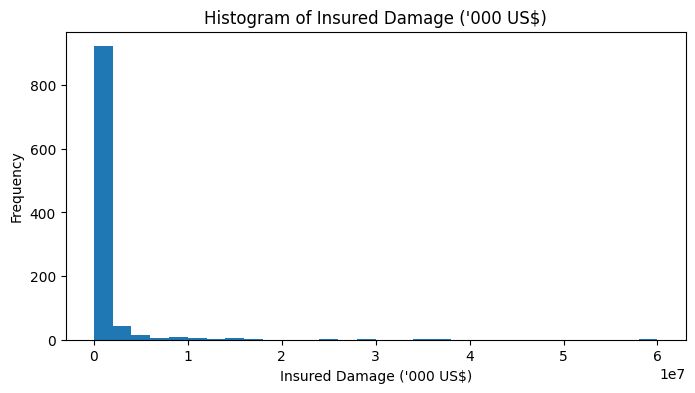

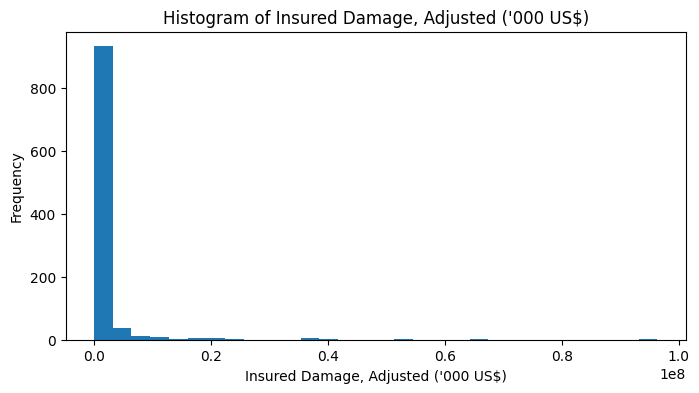

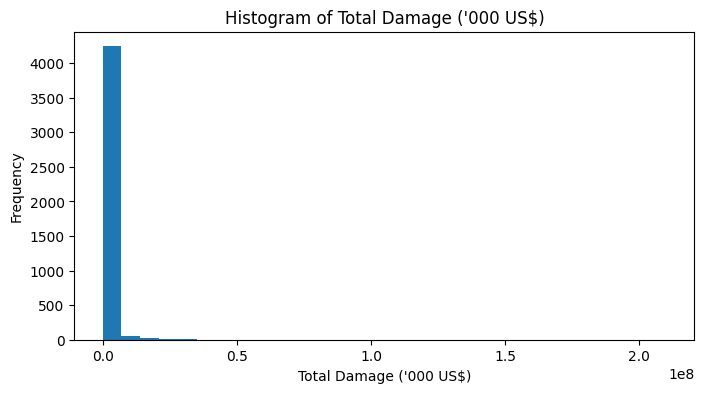

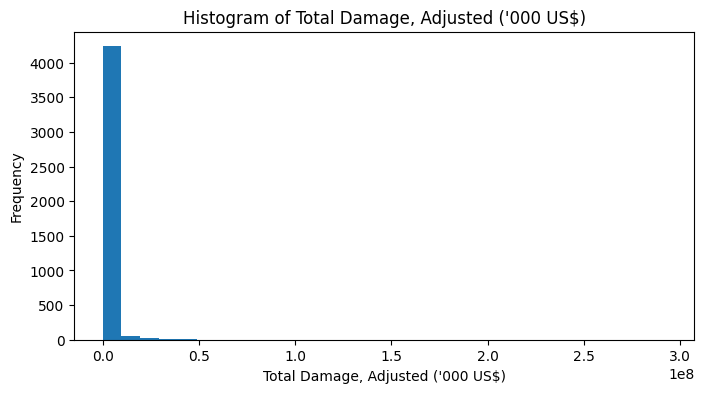

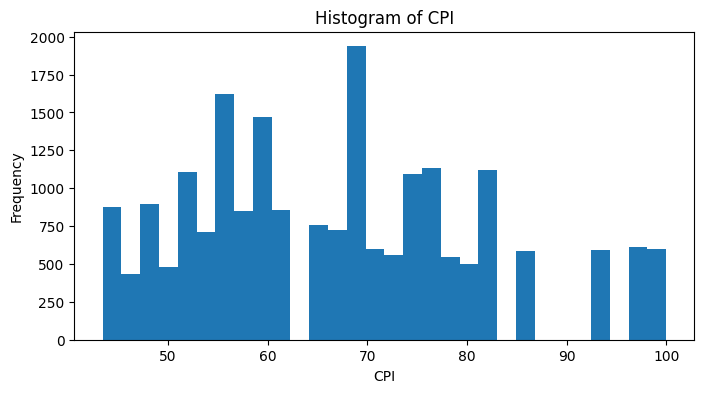

In [22]:
import matplotlib.pyplot as plt

num_cols = emdat.select_dtypes(include="number").columns.tolist()

for col in num_cols:
    plt.figure(figsize=(8, 4))
    emdat[col].dropna().hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(False)
    plt.show()

### Interpretation
Die Histogramme zeigen, dass viele Wirkungs- und Schadensvariablen stark rechtsschief verteilt sind. 
Die meisten Ereignisse weisen kleine Werte auf, während wenige Katastrophen sehr hohe Auswirkungen oder Schäden verursachen. 
Dies deutet auf starke Ausreißer hin und spricht dafür, in späteren Analysen gegebenenfalls logarithmische Transformationen zu verwenden.

## EDA für Climate-Dataset

In [9]:
print(climate)

<xarray.Dataset> Size: 150kB
Dimensions:                                    (time: 9405)
Coordinates:
  * time                                       (time) datetime64[ns] 75kB 199...
Data variables:
    MSL_filtered_GIA_corrected_adjusted        (time) float32 38kB ...
    trend_MSL_filtered_GIA_corrected_adjusted  (time) float32 38kB ...
Attributes:
    title:        Mediterranean Sea area Averaged Mean Sea Level from DUACS D...
    institution:  CLS
    references:   http://marine.copernicus.eu
    Conventions:  CF-1.7
    source:       The values are based on the two-satellite merged altimeter ...
    licence:      http://marine.copernicus.eu/services-portfolio/service-comm...
    area:         Mediterranean Sea
    comment:      Period : 1999-02-20 to 2024-11-19.
    credit:       E.U. Copernicus Marine Service Information
    contact:      https://marine.copernicus.eu/contact


In [ ]:
print("Data variables:", list(climate.data_vars))
print("Coordinates:", list(climate.coords))
print("Dimensions:", climate.dims)

Data variables: ['MSL_filtered_GIA_corrected_adjusted', 'trend_MSL_filtered_GIA_corrected_adjusted']
Coordinates: ['time']
Dimensions: FrozenMappingWarningOnValuesAccess({'time': 9405})


In [ ]:
# Umwandeln in DataFrame für eine tabellarische Ansicht
climate_df = climate.to_dataframe().reset_index()
print("Climate DataFrame shape:", climate_df.shape)
display(climate_df.head())

Climate DataFrame shape: (9405, 3)


,time,MSL_filtered_GIA_corrected_adjusted,trend_MSL_filtered_GIA_corrected_adjusted
0,1999-02-20,3.687602,2.171483
1,1999-02-21,3.684773,2.171927
2,1999-02-22,3.681582,2.172372
3,1999-02-23,3.678028,2.172817
4,1999-02-24,3.674113,2.173261


In [12]:
climate_df.isna().sum().sort_values(ascending=False)

time                                         0
MSL_filtered_GIA_corrected_adjusted          0
trend_MSL_filtered_GIA_corrected_adjusted    0
dtype: int64

In [13]:
climate_df.describe()

,time,MSL_filtered_GIA_corrected_adjusted,trend_MSL_filtered_GIA_corrected_adjusted
count,9405,9405.000000,9405.000000
mean,2012-01-05 00:00:00,5.963125,5.963297
min,1999-02-20 00:00:00,-0.416788,2.171483
25%,2005-07-29 00:00:00,3.405159,3.535554
50%,2012-01-05 00:00:00,5.681014,5.537774
75%,2018-06-13 00:00:00,8.220654,8.178143
max,2024-11-19 00:00:00,14.527944,11.456660
std,NaN,3.293798,2.707713


In [14]:
if "time" in climate_df.columns:
    print("Zeitspanne:", climate_df["time"].min(), "bis", climate_df["time"].max())
    print("Datentyp von time:", climate_df["time"].dtype)

Zeitspanne: 1999-02-20 00:00:00 bis 2024-11-19 00:00:00
Datentyp von time: datetime64[ns]


Erste Datenvariable: MSL_filtered_GIA_corrected_adjusted


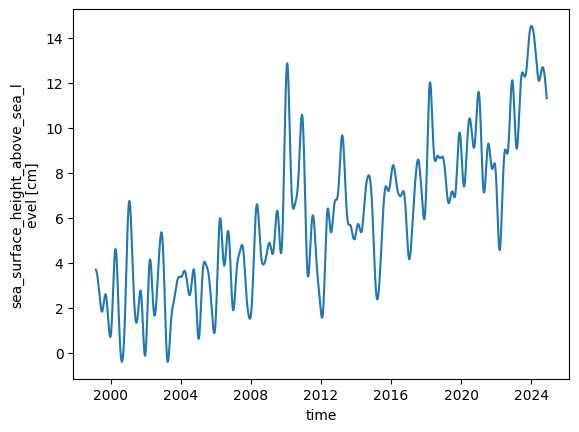

In [15]:
main_var = list(climate.data_vars)[0]
print("Erste Datenvariable:", main_var)

climate[main_var].plot()